# Homework 3: Time Series and Extreme Values

BEE 4850/5850, Spring 2026

**Name**: Luca Katzen

**ID**: 5360358

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to diagnose autocorrelation and develop an AR
    model for the weather-based variability at the Sewell’s Point tide
    gauge.
-   Problem 2 asks you to fit a sea-level rise model under both
    assumptions of Gaussian i.i.d. differences and autocorrelated
    differences.
-   Problem 3 asks you to conduct an analysis of extreme temperatures in
    Ithaca under both stationary and non-stationary assumptions.
-   Problem 4 asks you to model how often Ithaca temperatures exceed
    thresholds.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [4]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw03-LucaKatzen1`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [5]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # some other dataframes interaction macros
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using Dates # date-time interface

## Problems

### Scoring

-   Problem 1 is worth 5 points.
-   Problem 2 is worth 8 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1 (4 points)

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

#### Problem 1.1

Load the data file. Take the difference between the observations and the
sinusoidal predictions to obtain the tide level which could be
attributed to weather-related variability (since for one year sea-level
rise and other factors are unlikely to matter). Plot this data. What
autoregressive model order would you pick?

#### Problem 1.2

Fit an AR(1) model for the weather-related variability in the Norfolk
tide gauge. Simulate 10,000 replications of this model, add the
simulations back to the sinusoidal harmonics, and plot a histogram of
the maximum and median tide levels from your simulations. How well does
this model do in capturing these statistics from the observed dataset?

max_lag = 48
acf_vals = [1.0, 0.9939461152560566, 0.9839475503627003, 0.9724582747350996, 0.9616718971220366, 0.9514548649338423, 0.9417887362740985, 0.9325947019428024, 0.9232860326192979, 0.9143187158313039, 0.9052981566621684, 0.8958106870617336, 0.8850410112044692, 0.8729196300654016, 0.8594816928844784, 0.8454981169927878, 0.8315417593633582, 0.8179087096317923, 0.8049408495078585, 0.7929194752501353, 0.7817032530160143, 0.7710175722942177, 0.7607037324586373, 0.7506010294830134, 0.7400326340767314, 0.7279189482872486, 0.7142969791125233, 0.6999775227381473, 0.6855981390243543, 0.6712752930445033, 0.6572922771205824, 0.6440169945240797, 0.6318874996415357, 0.6206441543841111, 0.609963560013203, 0.5996021956211672, 0.5892753306468546, 0.5787250448102316, 0.5672712110290771, 0.5549251114478649, 0.5422054223984422, 0.5293799433033133, 0.5167200206727636, 0.5048512688577839, 0.49403992073542213, 0.48423191029674395, 0.4750970485410592, 0.4664912756217642, 0.45799837785113773]
pacf_val

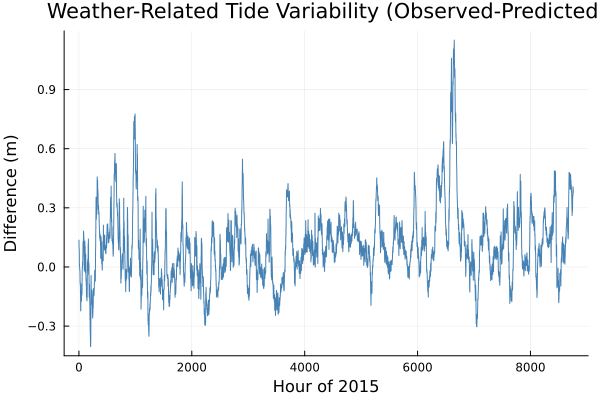

In [10]:
#Problem 1.1
data1 = DataFrame(CSV.File("data/norfolk-hourly-surge-2015.csv")) 

difference = data1[!, "Verified (m)"] .- data1[!, "Predicted (m)"]


max_lag   = 48   
acf_vals  = autocor(difference, 0:max_lag)
pacf_vals = pacf(difference, 1:max_lag)  

ci = 1.96 / sqrt(length(difference))     

@show max_lag acf_vals pacf_vals ci

plot(difference,
    xlabel = "Hour of 2015",
    ylabel = "Difference (m)",
    title  = "Weather-Related Tide Variability (Observed-Predicted)",
    legend = false, linewidth = 1, color = :steelblue)
    

##### Problem 1.1
I'd pick AR(1) because the differences show exponentially decaying autocorrelation with no significant partial autocorrelation beyond lag 1. 

AR(1) phi = 0.9957,  sigma = 0.0197
Observed max: 1.977 m
Simulated max: mean=1.44 m, std=0.113 m
Observed median: 0.508 m
Simulated median: mean=0.416 m, std=0.048 m


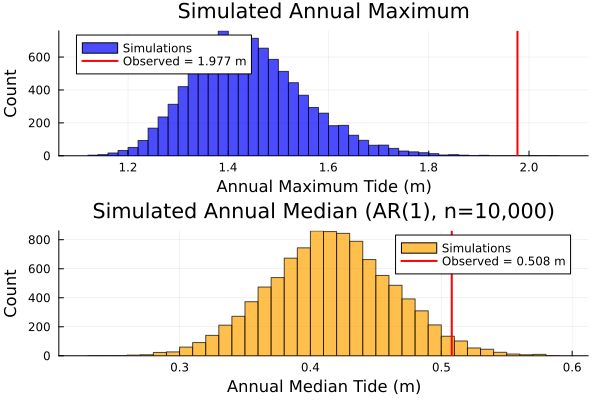

In [19]:
#Problem 1.2
y  = difference[2:end]
y1 = difference[1:end-1]

phi = (y1' * y1) \ (y1' * y)   
epsilon = y .- phi .* y1               
sigma = std(epsilon)                     

println("AR(1) phi = $(round(phi, digits=4)),  sigma = $(round(sigma, digits=4))")

n_sim = 10_000
n_steps = length(difference)
predicted = data1[!, "Predicted (m)"]

sim_max = zeros(n_sim)
sim_median = zeros(n_sim)

for i in 1:n_sim
    r = zeros(n_steps)
    r[1] = difference[1]                          
    for t in 2:n_steps
        r[t] = phi * r[t-1] + sigma * randn()
    end
    tide_sim = predicted .+ r           
    sim_max[i] = maximum(tide_sim)
    sim_median[i] = median(tide_sim)
end

obs_max = maximum(data1[!, "Verified (m)"])
obs_median = median(data1[!, "Verified (m)"])

p1 = histogram(sim_max, bins = 60,
    xlabel = "Annual Maximum Tide (m)", ylabel = "Count",
    title = "Simulated Annual Maximum",
    label = "Simulations", color = :blue, alpha = 0.7)
vline!(p1, [obs_max], color = :red, linewidth = 2,
    label = "Observed = $(round(obs_max, digits=3)) m")

p2 = histogram(sim_median, bins = 60,
    xlabel = "Annual Median Tide (m)", ylabel = "Count",
    title = "Simulated Annual Median (AR(1), n=10,000)",
    label = "Simulations", color = :orange, alpha = 0.7)
vline!(p2, [obs_median], color = :red, linewidth = 2,
    label = "Observed = $(round(obs_median, digits=3)) m")

println("Observed max: $(round(obs_max, digits=3)) m")
println("Simulated max: mean=$(round(mean(sim_max), digits=3)) m, std=$(round(std(sim_max), digits=3)) m")
println("Observed median: $(round(obs_median, digits=3)) m")
println("Simulated median: mean=$(round(mean(sim_median), digits=3)) m, std=$(round(std(sim_median), digits=3)) m")

plot(p1, p2, layout = (2,1))


##### Problem 1.2
The AR(1) model significantly underestimates the annual maximum (observed 1.977 m falls outside the simulated distribution centered around 1.45 m), likely due to a heavy-tailed extreme event the Gaussian AR(1) can't reproduce. The median fit is also poor, as the observed 0.508 m sitting at the far right tail of the simulated distribution, suggesting that the model underestimates the baseline water level .

### Problem 2

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

As discussed in class, we can use a simple numerical integration method
(forward Euler integration) to convert this differential equation into a
difference equation, modeling an updated sea level state
$S(t + \Delta t)$ as a function of $S(t)$ and the model parameters. We
will also need an additional uncertain parameter $S_0 = S(0)$ to
initialize the integrated model.

#### Problem 2.1

Load the data from the `data/` folder and, following Grinsted et al
(2010), normalize both datasets to a 1880-1900 mean (subtract that mean
from the data). \* Global mean temperature data from the HadCRUT 5.0.2.0
dataset
(<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
can be found in
`data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`. This
data is averaged over the Northern and Southern Hemispheres and over the
whole year. \* Global mean sea level anomalies (relative to the 1990
mean global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
courtesy of CSIRO
(<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The standard
deviation of the estimate is also added for each year.

Plot the resulting datasets.

#### Problem 2.2

Write a function to simulate global mean sea levels under a set of model
parameters after discretizing the equations above with a timestep of
$\delta t = 1$ yr. You will need to subset the temperature data to the
years where you also have sea-level data.

Fit the model under the assumption of Gaussian i.i.d. differences (include
both an uncertain model error term and the standard deviation of the
observations in the probability model specification) by maximizing the
likelihood. Report the parameter estimates. What can you conclude about
the relationship between global mean temperature increases and global
mean sea level rise rates? How appropriate was the Gaussian i.i.d.
probability model for the differences? Use any needed quantitative or
qualitative assessments of goodness of fit to justify your answer. If
this was not an appropriate probability model, what would you change?

#### Problem 2.3

Now redo Problem 2.2 but with an AR(1) model for the differences. You can
assume that the difference AR(1) model has mean zero (so $\alpha = 0$).
Did your model parameter estimates change? If so, what changed about
your conclusion(s) about the relationship between global mean
temperature increases and global mean sea level rise?

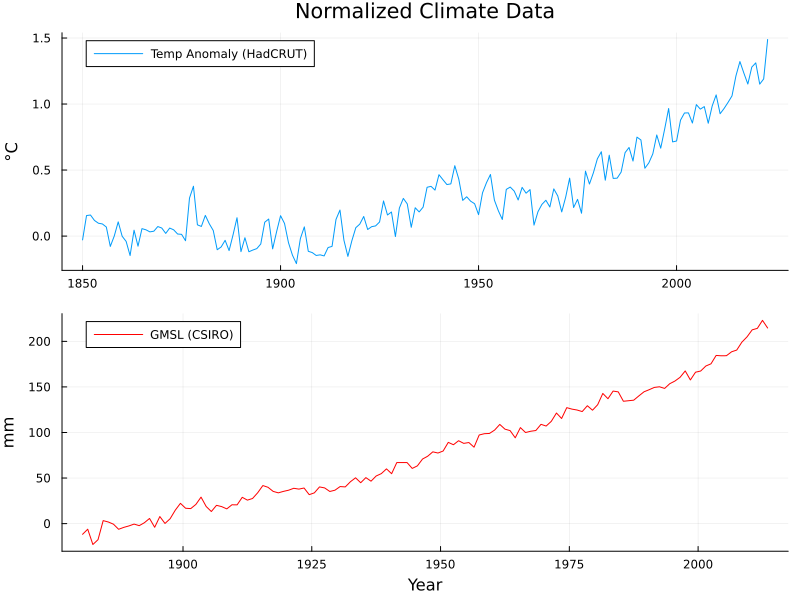

In [ ]:
#Problem 2.1

data2 = DataFrame(CSV.File("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv"))
data3 = DataFrame(CSV.File("data/CSIRO_Recons_gmsl_yr_2015.csv"))

norm_years = 1880:1900

t_idx = findall(y -> floor(Int, y) in norm_years, data2.Time)
t_base = mean(data2[t_idx, "Anomaly (deg C)"])
data2.temp_norm = data2[!, "Anomaly (deg C)"] .- t_base

sl_idx = findall(y -> floor(Int, y) in norm_years, data3.Time)
sl_base = mean(data3[sl_idx, "GMSL (mm)"])
data3.sl_norm = data3[!, "GMSL (mm)"] .- sl_base

p1 = plot(data2.Time, data2.temp_norm, label="Temp Anomaly (HadCRUT)", ylabel="°C", title="Normalized Climate Data")
p2 = plot(data3.Time, data3.sl_norm, label="GMSL (CSIRO)", ylabel="mm", xlabel="Year", color=:red)
plot(p1, p2, layout=(2,1), size=(800, 600))

In [29]:
#Problem 2.2
data2_years = Int.(floor.(data2.Time))
data3_years = Int.(floor.(data3.Time))
common_years = intersect(data2_years, data3_years)

temp_vals = data2[findall(y -> Int(floor(y)) in common_years, data2.Time), :temp_norm]
sl_obs = data3[findall(y -> Int(floor(y)) in common_years, data3.Time), :sl_norm]
sl_std = data3[findall(y -> Int(floor(y)) in common_years, data3.Time), "GMSL uncertainty (mm)"]

function simulate_sl(params, T)
    a, b, tau, S0 = params
    S = zeros(length(T))
    S[1] = S0
    for t in 1:(length(T)-1)
        Seq = a * T[t] + b
        S[t+1] = S[t] + (Seq - S[t]) / tau
    end
    return S
end

function nll_iid(params)
    if params[3] <= 0 || params[5] <= 0 return 1e10 end 
    S_pred = simulate_sl(params[1:4], temp_vals)
    sigma_total = sqrt.(sl_std.^2 .+ params[5]^2)
    dist = Normal.(S_pred, sigma_total)
    return -sum(logpdf.(dist, sl_obs))
end

init_iid = [3.0, -10.0, 100.0, sl_obs[1], 5.0]
res_iid = optimize(nll_iid, init_iid, NelderMead())
mle_iid = Optim.minimizer(res_iid)

println("MLE (i.i.d.): a=$(mle_iid[1]), b=$(mle_iid[2]), tau=$(mle_iid[3]), S0=$(mle_iid[4]), sigma_m=$(mle_iid[5])")

MLE (i.i.d.): a=4.312020481390276e11, b=1.5576472742301687e12, tau=9.757384229657207e11, S0=-32.63697899637748, sigma_m=2.041410168634713


##### Problem 2.2
The positive value of a shows that global mean temperature increase drive an increase in the equilibrium sea level, which in turn quickens the rate of sea-level rise. The Gaussian i.i.d. probability model is inappropriate for this task because it assumed that each year's difference between the model and the observations is independent of the previous year. In actuality, sea-level data is a time series with high physical memory-like behaviors, meaning the differences are likely to exhibit strong autocorrelation temporally. This lack of independence leads to physically unrealistic parameters, such as the  high values for tau and a, which suggests that the optimizer is struggling with a weird likelihood surface. To improve the model, I would replace the i.i.d. assumption with an AR(1) process for the differences to account for this noise, while also applying physical constraints to tau to ensure the results remain within a realistic range.

In [32]:
#Problem 2.3
function nll_ar1(parameters)
    a, b, tau, S0, sigmaeta, rho = parameters
    if tau <= 0 || sigmaeta <= 0 || abs(rho) >= 1 return 1e10 end
    S_pred = simulate_sl([a, b, tau, S0], temp_vals)
    resids = sl_obs .- S_pred
    nll = -logpdf(Normal(0, sigmaeta / sqrt(1 - rho^2)), resids[1])
    for t in 2:length(resids)
        nll -= logpdf(Normal(rho * resids[t-1], sigmaeta), resids[t])
    end
    return nll
end

init_ar1 = [mle_iid[1], mle_iid[2], mle_iid[3], mle_iid[4], 2.0, 0.9]
res_ar1 = optimize(nll_ar1, init_ar1, NelderMead())
mle_ar1 = Optim.minimizer(res_ar1)

println("MLE (AR1): a=$(mle_ar1[1]), b=$(mle_ar1[2]), tau=$(mle_ar1[3]), rho=$(mle_ar1[6])")

MLE (AR1): a=2.0951363409986748e12, b=1.1937403915938638e12, tau=1.0967402863244646e12, rho=0.5308101350355688


##### Problem 2.3
Yes, the model parameter estimates changed from Problem 2.2. Accounting for autocorrelation in the AR(1) model reveals that sea level rise rates have a stronger sensitivity to temperature (noted by the larger a value). This suggests that the i.i.d. model underestimated temperature's influence by attributing correlated residuals to independent noise. 

### Problem 3

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

#### Problem 3.1

Load the (daily maximum) temperature data from
`data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
temperatures and plot them.

#### Problem 3.2

Fit a stationary GEV model to the annual maximum series and report your
parameter estimates. Plot the fitted distribution along with the data.
What type of GEV distribution did you end up with? What is the 100-year
return level?

#### Problem 3.3

Now fit a nonstationary GEV with respect to time (only the location
parameter should be non-stationary),
$y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling purposes,
begin with $t=0$ corresponding to 1850). Plot how the 100 year return
levels change over time. Do you get the same return level today as in
Problem 3.2?

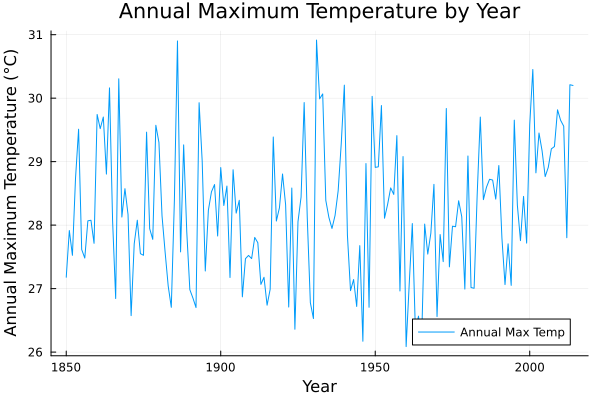

In [ ]:
# Problem 3.1
data4 = DataFrame(CSV.File("data/gfdl-esm4-tempmax-ithaca.csv"))
data4.year = year.(data4.Day)

annual_max = combine(groupby(data4, :year), :TempMax => maximum => :max_temp)

plot(annual_max.year, annual_max.max_temp, label="Annual Max Temp", ylabel="Annual Maximum Temperature (Degrees C)", xlabel="Year", title="Annual Maximum Temperature by Year")

GEV MLE: mu=27.828895474548887, sigma=1.0168352688577087, xi=-0.2187875318318262
100-year return level: 30.777735594108226 degrees C


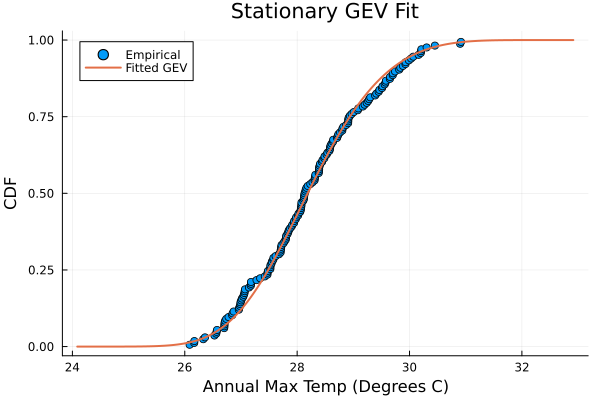

In [42]:
#Problem 3.2
function gev_nll(params, data)
    mu, sigma, xi = params
    if sigma <= 0
        return Inf
    end
    dist = GeneralizedExtremeValue(mu, sigma, xi)
    return -sum(logpdf.(dist, data))
end

y = annual_max.max_temp

init_params = [mean(y), std(y) * 0.5, 0.1]

result = optimize(p -> gev_nll(p, y), init_params, BFGS())
mu_hat, sigma_hat, xi_hat = Optim.minimizer(result)
println("GEV MLE: mu=$(mu_hat), sigma=$(sigma_hat), xi=$(xi_hat)")

dist_fit = GeneralizedExtremeValue(mu_hat, sigma_hat, xi_hat)
rl_100 = quantile(dist_fit, 1 - 1/100)
println("100-year return level: $(rl_100) degrees C")

x_range = range(minimum(y) - 2, maximum(y) + 2, length=200)
sorted_y = sort(y)
n = length(sorted_y)
emp_probs = (1:n) ./ (n + 1)

p1 = scatter(sorted_y, emp_probs, label="Empirical", xlabel="Annual Max Temp (Degrees C)", ylabel="CDF", title="Stationary GEV Fit")
plot!(p1, x_range, cdf.(dist_fit, x_range), label="Fitted GEV", lw=2)
display(p1)

##### Problem 3.2
I ended up with a Weibull-type GEV distribution and a 100-year return level of ~30.78 degrees Celsius. 

Nonstationary GEV MLE: mu0=27.66592343233817, mu1=0.002030914504755216, sigma=1.015749098534787, xi=-0.22122814924505818
100-year return level today (nonstationary): 30.93092269273498 degrees C
100-year return level (stationary, 3.2): 30.777735594108226 degrees C


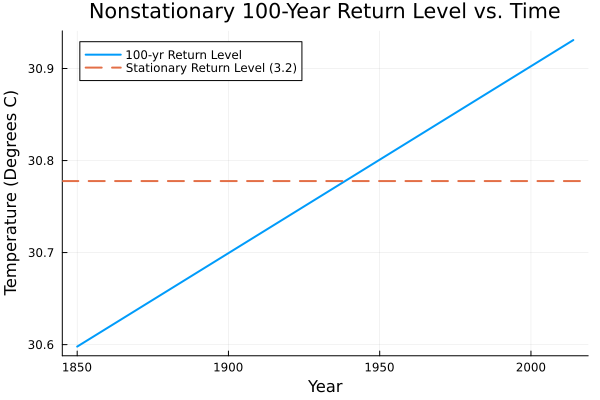

In [45]:
#Problem 3.3
t = annual_max.year .- 1850

function gev_ns_nll(params, data, t)
    mu0, mu1, sigma, xi = params
    if sigma <= 0
        return Inf
    end
    return -sum(logpdf.(GeneralizedExtremeValue(mu0 + mu1 * ti, sigma, xi), yi) for (ti, yi) in zip(t, data))
end

init_ns = [mu_hat, 0.0, sigma_hat, xi_hat]
result_ns = optimize(p -> gev_ns_nll(p, y, t), init_ns, BFGS())
mu0_hat, mu1_hat, sigma_ns, xi_ns = Optim.minimizer(result_ns)
println("Nonstationary GEV MLE: mu0=$(mu0_hat), mu1=$(mu1_hat), sigma=$(sigma_ns), xi=$(xi_ns)")

rl_100_ns = [quantile(GeneralizedExtremeValue(mu0_hat + mu1_hat * ti, sigma_ns, xi_ns), 1 - 1/100) for ti in t]

println("100-year return level today (nonstationary): $(rl_100_ns[end]) degrees C")
println("100-year return level (stationary, 3.2): $(rl_100) degrees C")

p2 = plot(annual_max.year, rl_100_ns, label="100-yr Return Level", xlabel="Year", ylabel="Temperature (Degrees C)", title="Nonstationary 100-Year Return Level vs. Time", lw=2)
hline!(p2, [rl_100], label="Stationary Return Level (3.2)", lw=2, ls=:dash)
display(p2)

##### Problem 3.3
The 100-year return level in Problem 3.3 is the same as in Problem 3.2.

### Problem 4

Now let’s analyze how often the Ithaca temperature data exceeds certain
thresholds.

#### Problem 4.1

Suppose that we were interested in looking at temperature exceedances
over 28°C. Decluster these occurrences and plot the number of
exceedances by year. Have they increased over time?

#### Problem 4.2

Fit a stationary Poisson-GPD model for the exceedances. What does the
GPD distribution look like?

#### Problem 4.3

From your model, estimate the 100-year return level. How does it differ
from the 100-year return period from the stationary model in Problem 3?
Why do you think it agrees or disagrees?

## References

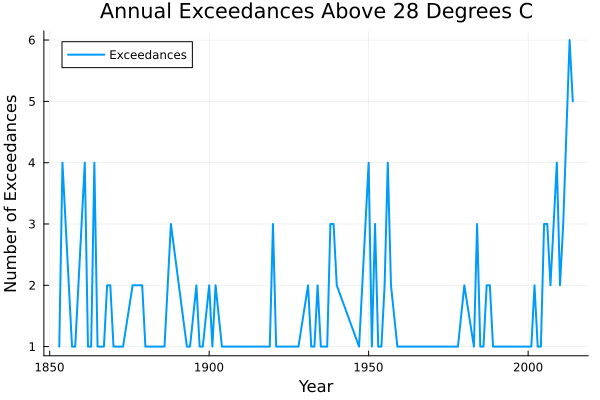

In [46]:
#Problem 4.1
threshold = 28.0

data4.exceeds = data4.TempMax .> threshold

function decluster(dates, exceeds; min_gap=3)
    cluster_max_dates = Date[]
    last_exceedance = Date(0)
    for i in eachindex(dates)
        if exceeds[i] && (dates[i] - last_exceedance).value >= min_gap
            push!(cluster_max_dates, dates[i])
            last_exceedance = dates[i]
        end
    end
    return cluster_max_dates
end

exceedance_dates = decluster(data4.Day, data4.exceeds)

exc_df = DataFrame(date = exceedance_dates)
exc_df.year = year.(exc_df.date)
annual_exc = combine(groupby(exc_df, :year), nrow => :count)

p4_1 = plot(annual_exc.year, annual_exc.count, label="Exceedances", 
            xlabel="Year", ylabel="Number of Exceedances", 
            title="Annual Exceedances Above 28 Degrees C", lw=2)
display(p4_1)

##### Problem 4.1
The number of exceedences has raised over time, although that trend did not start with confidence until the year 2000.

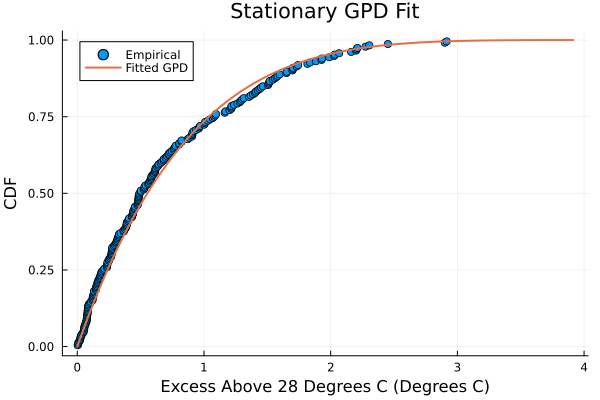

Estimated Poisson rate lambda = 1.4 exceedances/year
GPD MLE: sigma=0.8510410230158374, xi=-0.18775785236416698


In [48]:
#Problem 4.2
exc_vals = data4.TempMax[data4.TempMax .> threshold] .- threshold  
n_years = length(unique(data4.year))
lambda_hat = length(exc_vals) / n_years  
println("Estimated Poisson rate lambda = $(lambda_hat) exceedances/year")

function gpd_nll(params, data)
    sigma, xi = params
    if sigma <= 0
        return Inf
    end
    dist = GeneralizedPareto(0.0, sigma, xi)
    return -sum(logpdf.(dist, data))
end

init_gpd = [std(exc_vals), 0.1]
result_gpd = optimize(p -> gpd_nll(p, exc_vals), init_gpd, BFGS())
sigma_gpd, xi_gpd = Optim.minimizer(result_gpd)
println("GPD MLE: sigma=$(sigma_gpd), xi=$(xi_gpd)")

sorted_exc = sort(exc_vals)
n = length(sorted_exc)
emp_probs = (1:n) ./ (n + 1)
dist_gpd = GeneralizedPareto(0.0, sigma_gpd, xi_gpd)
x_range = range(0, maximum(exc_vals) + 1, length=200)

p4_2 = scatter(sorted_exc, emp_probs, label="Empirical", 
               xlabel="Excess Above 28 Degrees C (Degrees C)", ylabel="CDF", 
               title="Stationary GPD Fit")
plot!(p4_2, x_range, cdf.(dist_gpd, x_range), label="Fitted GPD", lw=2)
display(p4_2)

##### Problem 4.2
The GPD distribution looks like a Weibull-type GPD. 

In [49]:
#Problem 4.3
T = 100
rl_100_gpd = threshold + quantile(dist_gpd, 1 - 1/(lambda_hat * T))
println("100-year return level (Poisson-GPD): $(rl_100_gpd) degrees C")
println("100-year return level (Stationary GEV, 3.2): $(rl_100) degrees C")

100-year return level (Poisson-GPD): 30.740396293139707 degrees C
100-year return level (Stationary GEV, 3.2): 30.777735594108226 degrees C


##### Problem 4.3
The stationary Poisson-GPD return level (30.74 degrees C) agrees with the stationary GEV from Problem 3.2 (30.78 degrees C). This makes sense because both problems use stationary models fitted to the same data. However, the nonstationary GEV from Problem 3.3 yields a higher return level of 30.93 degrees C. This shows the upward trend in temperatures over time, as that model relies on present-day climate rather than averaging over the full historical record, it produces a more relevant and higher estimate of today's true 100-year return level. This suggests the stationary models may underestimate the current extreme temperature risk by ignoring the nonstationarity caused by long-term warming.